# Optical Propertise for g-BC3

Optical propertise versus energy

## Optical propertise versus energy

Data labe: `dielectricfunction`

+ 1st: Imaginary part of Density-Density

+ 2nd: Real part of Density-Density

+ 3th: Imaginary part of Currnet-Current

+ 4th: Real part of Currnet-Current

+ 5th: Conductivity

+ 6th: DOS


In [1]:
#### Loop testing

fruits = ["apple", "banana", "cherry", "Durian"]

for i, fruit in enumerate(fruits[0:2]):
    print(f"Index: {i}, Fruit: {fruit}")

Index: 0, Fruit: apple
Index: 1, Fruit: banana


In [2]:
#### Declarations of process functions for Optical Propertises

### Necessary packages invoking
import numpy as np
import xml.etree.ElementTree as ET

### Physical constants
hbar = 4.135667662e-15
c_vacuum = 2.99792458e8

### Extract optical propertises from vasprun.xml
def extract_opt_vectorized(file_path):
    ## Analysis vasprun.xml file
    tree = ET.parse(file_path)
    root = tree.getroot()
    data_label = "dielectricfunction"

    ## Extract NEDOS
    nedos_element = root.find(".//i[@name='NEDOS']")
    nedos = int(nedos_element.text.strip())

    ## Loop variables
    # Define prefixes: 
        # e_ for Density-Density (Charge density response)
        # c_ for Current-Current (Current response)
    prefixes = ["e_", "c_"]
    # Initialize a dictionary to store dynamic variables
    data = {}

    ## Extract imaginary part of Density-Density and Current-Current
    imag_path = f".//{data_label}/imag/array/set"
    imag_elements = root.findall(imag_path)
    for loop_index, imag_element in enumerate(imag_elements[0:2]):
        # Select prefix based on the loop index
        prefix = prefixes[loop_index]
        # Initialize columns as lists
        columns = ["energy_imag_col", 
                   "xx_imag_col", "yy_imag_col", "zz_imag_col", "xy_imag_col", "yz_imag_col", "zx_imag_col"]
        for col in columns:
            data[prefix + col] = []
        # Append data to lists
        for imag_index in imag_element.findall("r"):
            imag_values = list(map(float, imag_index.text.split()))
            for value_index, col in enumerate(columns):
                data[prefix + col].append(imag_values[value_index])
        # Convert lists to numpy arrays
        for col in columns:
            data[prefix + col] = np.array(data[prefix + col])

    ## Extract real part of Density-Density and Current-Current
    real_path = f".//{data_label}/real/array/set"
    real_elements = root.findall(real_path)
    for loop_index, real_element in enumerate(real_elements[0:2]):
        # Select prefix based on the loop index
        prefix = prefixes[loop_index]
        # Initialize columns as lists
        columns = ["energy_real_col", 
                   "xx_real_col", "yy_real_col", "zz_real_col", "xy_real_col", "yz_real_col", "zx_real_col"]
        for col in columns:
            data[prefix + col] = []
        # Append data to lists
        for real_index in real_element.findall("r"):
            real_values = list(map(float, real_index.text.split()))
            for value_index, col in enumerate(columns):
                data[prefix + col].append(real_values[value_index])
        # Convert lists to numpy arrays
        for col in columns:
            data[prefix + col] = np.array(data[prefix + col])
    
    ## Extract Fermi energy
    efermi_element = root.find(".//dos/i[@name='efermi']")
    fermi_energy = float(efermi_element.text.strip())

    ## Extract Conductivity
    conductivity_path = ".//conductivity[@comment='spin=1']/array/set"
    conductivity_set_element = tree.find(conductivity_path)
    # Initialize columns as lists
    columns = ["conductivity_energy", 
               "conductivity_xx", "conductivity_yy", "conductivity_zz", "conductivity_xy", "conductivity_yz", "conductivity_zx"]
    # Initialize dictionary
    conductivity_data = {col: [] for col in columns}
    for conductivity_index in conductivity_set_element.findall("r"):
        values = list(map(float, conductivity_index.text.split()))
        conductivity_data["conductivity_energy"].append(values[0])
        conductivity_data["conductivity_xx"].append(values[1])
        conductivity_data["conductivity_yy"].append(values[2])
        conductivity_data["conductivity_zz"].append(values[3])
        conductivity_data["conductivity_xy"].append(values[4])
        conductivity_data["conductivity_yz"].append(values[5])
        conductivity_data["conductivity_zx"].append(values[6])

    ## Extract DOS
    dos_path = ".//dos/total/array/set/set[@comment='spin 1']"
    dos_set_element = tree.find(dos_path)
    # Initialize columns as lists
    columns = ["dos_energy", "total_dos", "integrated_dos"]
    # Initialize dictionary
    dos_data = {col: [] for col in columns}
    for dos_index in dos_set_element.findall("r"):
        values = list(map(float, dos_index.text.split()))
        dos_data["dos_energy"].append(values[0])
        dos_data["total_dos"].append(values[1])
        dos_data["integrated_dos"].append(values[2])

    return (nedos,                                      #  [0]: NEDOS
            data["e_energy_imag_col"],                  #  [1]: imaginary part of energy of Density-Density
            data["e_xx_imag_col"],                      #  [2]: imaginary part of xx direction of Density-Density
            data["e_yy_imag_col"],                      #  [3]: imaginary part of yy direction of Density-Density
            data["e_zz_imag_col"],                      #  [4]: imaginary part of zz direction of Density-Density
            data["e_xy_imag_col"],                      #  [5]: imaginary part of xy direction of Density-Density
            data["e_yz_imag_col"],                      #  [6]: imaginary part of yz direction of Density-Density
            data["e_zx_imag_col"],                      #  [7]: imaginary part of zx direction of Density-Density
            data["c_energy_imag_col"],                  #  [8]: imaginary part of energy of Current-Current
            data["c_xx_imag_col"],                      #  [9]: imaginary part of xx direction of Current-Current
            data["c_yy_imag_col"],                      # [10]: imaginary part of yy direction of Current-Current
            data["c_zz_imag_col"],                      # [11]: imaginary part of zz direction of Current-Current
            data["c_xy_imag_col"],                      # [12]: imaginary part of xy direction of Current-Current
            data["c_yz_imag_col"],                      # [13]: imaginary part of yz direction of Current-Current
            data["c_zx_imag_col"],                      # [14]: imaginary part of zx direction of Current-Current
            data["e_energy_real_col"],                  # [15]: real part of energy of Density-Density
            data["e_xx_real_col"],                      # [16]: real part of xx direction of Density-Density
            data["e_yy_real_col"],                      # [17]: real part of yy direction of Density-Density
            data["e_zz_real_col"],                      # [18]: real part of zz direction of Density-Density
            data["e_xy_real_col"],                      # [19]: real part of xy direction of Density-Density
            data["e_yz_real_col"],                      # [20]: real part of yz direction of Density-Density
            data["e_zx_real_col"],                      # [21]: real part of zx direction of Density-Density
            data["c_energy_real_col"],                  # [22]: real part of energy of Current-Current
            data["c_xx_real_col"],                      # [23]: real part of xx direction of Current-Current
            data["c_yy_real_col"],                      # [24]: real part of yy direction of Current-Current
            data["c_zz_real_col"],                      # [25]: real part of zz direction of Current-Current
            data["c_xy_real_col"],                      # [26]: real part of xy direction of Current-Current
            data["c_yz_real_col"],                      # [27]: real part of yz direction of Current-Current
            data["c_zx_real_col"],                      # [28]: real part of zx direction of Current-Current
            data_label,                                 # [29]: data label
            fermi_energy,                               # [30]: system Fermi energy
            conductivity_data["conductivity_energy"],   # [31]: energy of conductivity
            conductivity_data["conductivity_xx"],       # [32]: xx direction of conductivity
            conductivity_data["conductivity_yy"],       # [33]: yy direction of conductivity
            conductivity_data["conductivity_zz"],       # [34]: zz direction of conductivity
            conductivity_data["conductivity_xy"],       # [35]: xy direction of conductivity
            conductivity_data["conductivity_yz"],       # [36]: yz direction of conductivity
            conductivity_data["conductivity_zx"],       # [37]: zx direction of conductivity
            dos_data["dos_energy"],                     # [38]: energy list of DOS
            dos_data["total_dos"],                      # [39]: total DOS
            dos_data["integrated_dos"],                 # [40]: integrated DOS
            )


In [3]:
##### Data Process

## File path (you should update this to the correct file path)
opt_file_path = "6_Optical_properties_gamma/vasprun.xml"

results = extract_opt_vectorized(opt_file_path)

nedos = results[0]

density_imag_energy = results[1]
density_imag_xx = results[2]
density_imag_yy = results[3]
density_imag_zz = results[4]
density_imag_xy = results[5]
density_imag_yz = results[6]
density_imag_zx = results[7]

current_imag_energy = results[8]
current_imag_xx = results[9]
current_imag_yy = results[10]
current_imag_zz = results[11]
current_imag_xy = results[12]
current_imag_yz = results[13]
current_imag_zx = results[14]

density_real_energy = results[15]
density_real_xx = results[16]
density_real_yy = results[17]
density_real_zz = results[18]
density_real_xy = results[19]
density_real_yz = results[20]
density_real_zx = results[21]

current_real_energy = results[22]
current_real_xx = results[23]
current_real_yy = results[24]
current_real_zz = results[25]
current_real_xy = results[26]
current_real_yz = results[27]
current_real_zx = results[28]

data_label = results[29]
fermi_energy  = results[30]

conductivity_energy = results[31]
conductivity_xx = results[32]
conductivity_yy = results[33]
conductivity_zz = results[34]
conductivity_xy = results[35]
conductivity_yz = results[36]
conductivity_zx = results[37]

dos_energy = results[38]
total_dos = results[39]
integrated_dos = results[40]


In [4]:
##### Data Testing

# print(f"NEDOS: {nedos}")
# print(f"Data label: {data_label}")

# print(f"Density Imaginary Energy: {density_imag_energy}")
# print(f"Density Imaginary xx: {density_imag_xx}")
# print(f"Density Imaginary yy: {density_imag_yy}")
# print(f"Density Imaginary zz: {density_imag_zz}")
# print(f"Density Imaginary xy: {density_imag_xy}")
# print(f"Density Imaginary yz: {density_imag_yz}")
# print(f"Density Imaginary zx: {density_imag_zx}")

# print(f"Density Real Energy: {density_real_energy}")
# print(f"Density Real xx: {density_real_xx}")
# print(f"Density Real yy: {density_real_yy}")
# print(f"Density Real zz: {density_real_zz}")
# print(f"Density Real xy: {density_real_xy}")
# print(f"Density Real yz: {density_real_yz}")
# print(f"Density Real zx: {density_real_zx}")

# print(f"Current Imaginary Energy: {current_imag_energy}")
# print(f"Current Imaginary xx: {current_imag_xx}")
# print(f"Current Imaginary yy: {current_imag_yy}")
# print(f"Current Imaginary zz: {current_imag_zz}")
# print(f"Current Imaginary xy: {current_imag_xy}")
# print(f"Current Imaginary yz: {current_imag_yz}")
# print(f"Current Imaginary zx: {current_imag_zx}")

# print(f"Current Real Energy: {current_real_energy}")
# print(f"Current Real xx: {current_real_xx}")
# print(f"Current Real yy: {current_real_yy}")
# print(f"Current Real zz: {current_real_zz}")
# print(f"Current Real xy: {current_real_xy}")
# print(f"Current Real yz: {current_real_yz}")
# print(f"Current Real zx: {current_real_zx}")

# print(f"Fermi energy: {fermi_energy}")

# print(f"Conductivity Energy: {len(conductivity_energy)}")
# print(f"Conductivity xx: {len(conductivity_xx)}, {conductivity_xx}")
# print(f"Conductivity yy: {len(conductivity_yy)}, {conductivity_yy}")
# print(f"Conductivity zz: {len(conductivity_zz)}, {conductivity_zz}")
# print(f"Conductivity xy: {len(conductivity_xy)}, {conductivity_xy}")
# print(f"Conductivity yz: {len(conductivity_yz)}, {conductivity_yz}")
# print(f"Conductivity zx: {len(conductivity_zx)}, {conductivity_zx}")

# print(f"Energy of DOS: {len(dos_energy)}, {dos_energy}")
# print(f"Total DOS: {len(total_dos)}, {total_dos}")
# print(f"Integrated DOS: {len(integrated_dos)}, {integrated_dos}")


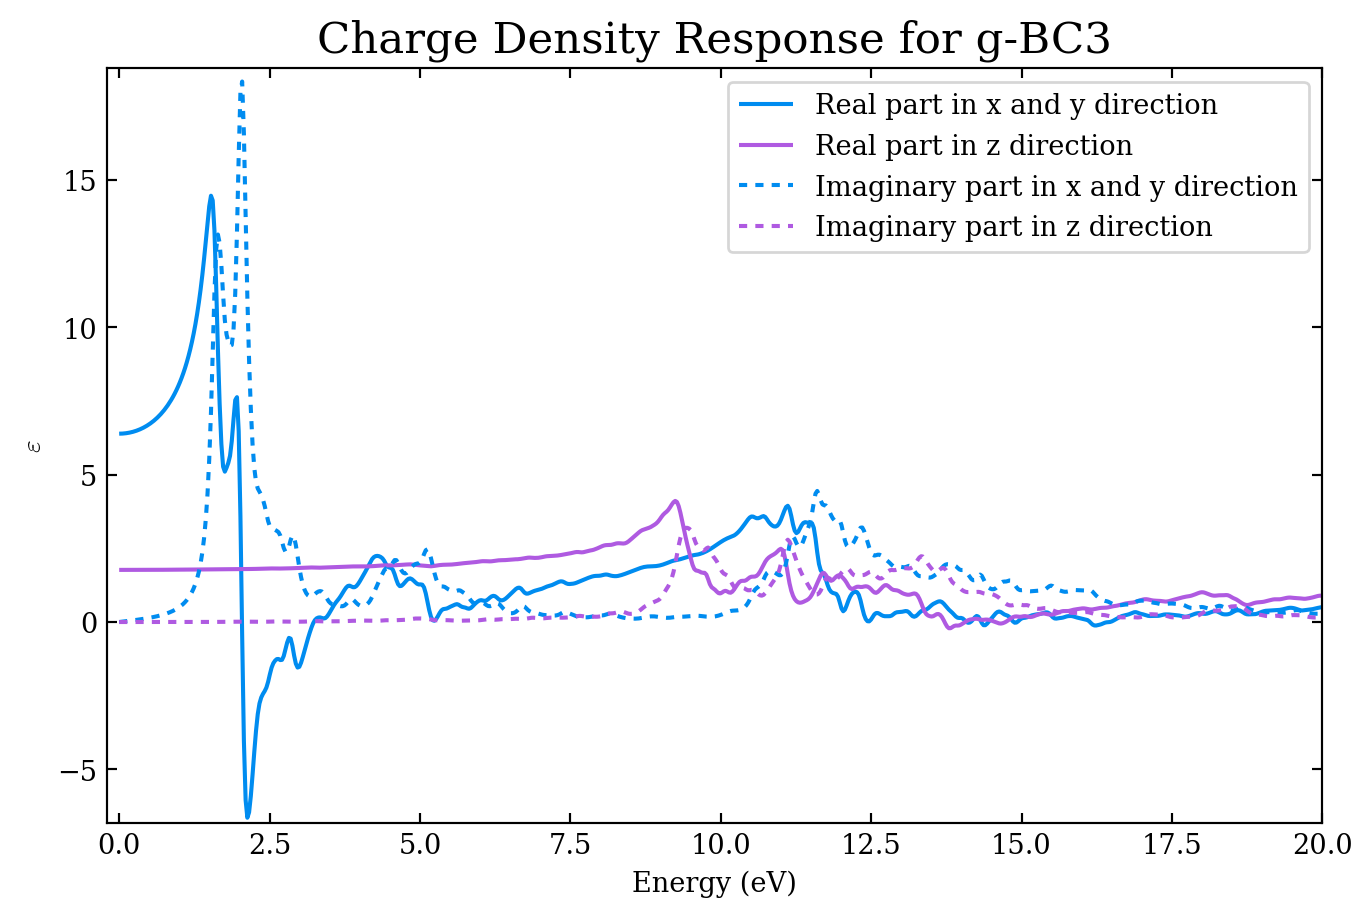

In [5]:
#### Ploting for Charge Density Response

### Import the necessary packages for plotting
import matplotlib.pyplot as plt
import numpy as np

### Set up the specified style parameters
plt.figure(dpi=196, figsize=(8, 5))
params = {"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm", "axes.titlesize": 16, "axes.labelsize": 14, "figure.facecolor": "w"}
plt.rcParams.update(params)
plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

### Title and labels
plt.title("Charge Density Response for g-BC3"); plt.xlabel(r"Energy (eV)"); plt.ylabel(r"$\varepsilon$")

max_value = np.max([density_imag_xx, density_imag_yy, density_imag_zz, 
                    density_real_xx, density_real_yy, density_real_zz])
min_value = np.min([density_imag_xx, density_imag_yy, density_imag_zz, 
                    density_real_xx, density_real_yy, density_real_zz])

### Plot data
## Plot CDR data from vasprun.xml
y_inf = min_value * 1.025
y_sup = max_value * 1.025
x_range = 20
width_base = 1.5
width_factor = 1

## Plot CDR
# Real part
lines = plt.plot(density_real_energy,  density_real_xx, c="#008CF0", linewidth=width_base*width_factor, label=r"Real part in x and y direction")
lines[0].set_dashes([2/width_factor, 0/width_factor])
# lines = plt.plot(density_real_energy,  density_real_yy, c="#F05F0A", linewidth=width_base , label=r"Real part in y direction")
# lines[0].set_dashes([2, 0])
lines = plt.plot(density_real_energy,  density_real_zz, c="#AF5AE1", linewidth=width_base , label=r"Real part in z direction")
lines[0].set_dashes([2, 0])
# Imaninary part
lines = plt.plot(density_imag_energy,  density_imag_xx, c="#008CF0", linewidth=width_base*width_factor, label=r"Imaginary part in x and y direction")
lines[0].set_dashes([2/width_factor, 2/width_factor])
# lines = plt.plot(density_imag_energy,  density_imag_yy, c="#F05F0A", linewidth=width_base , label=r"Imaginary part in y direction")
# lines[0].set_dashes([2, 2])
lines = plt.plot(density_imag_energy,  density_imag_zz, c="#AF5AE1", linewidth=width_base , label=r"Imaginary part in z direction")
lines[0].set_dashes([2, 2])

plt.ylim(y_inf, y_sup)
plt.xlim(-x_range*0.01, x_range)
plt.legend(loc="best")
